# Exploratory Data Analysis for ATLAS Boosted Top Tagging

**Course:** Machine Learning for Physics and Astrophysics  
**Project:** Deep Learning for Top Quark Identification with ATLAS Open Data  
**Notebook:** 01 — Data Exploration  

---

## Aim

This notebook is the **first step** of the project. Its purpose is purely exploratory: we inspect the ATLAS Top Tagging Open Data, understand the physics task, and produce diagnostic plots that will guide all subsequent modelling decisions.

No neural network is trained here. Instead, we:

- introduce the physics of boosted top-quark jets and why tagging them is non-trivial;
- formulate the problem precisely as a binary classification task;
- inspect the HDF5 file structure and verify the data matches expectations;
- study jet-level kinematics, constituent-level quantities, angular structure, and high-level substructure features;
- visualise individual and averaged jet images in the $\eta$–$\phi$ plane;
- identify the preprocessing steps that will be needed in later notebooks.

The findings here directly motivate the architecture choices in later notebooks.

---

## 1. Physics Background: Boosted Top Tagging

### 1.1 Jets at the LHC

At the Large Hadron Collider (LHC), proton–proton collisions at $\sqrt{s} = 13$ TeV produce quarks and gluons as primary outgoing particles. Because of colour confinement, free quarks and gluons cannot exist in isolation; they immediately undergo a process called **hadronisation**, producing a collimated spray of hadrons (pions, kaons, protons, etc.) travelling in roughly the same direction. This spray is called a **jet**.

Jets are reconstructed from energy deposits in the calorimeter (and sometimes also from tracking information) using clustering algorithms such as the anti-$k_t$ algorithm. For this dataset, **large-radius jets** are used, reconstructed with radius parameter $R = 1.0$, which subtend a cone of $\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2} \leq 1.0$ around the jet axis.

### 1.2 The Top Quark and its Hadronic Decay

The top quark ($t$) is the heaviest known elementary particle, with mass $m_t \approx 173$ GeV. It decays almost exclusively via $t \to W b$. When the $W$ boson decays hadronically ($W \to q\bar{q}'$), the full top quark decay chain is:

$$t \;\to\; W^+ b \;\to\; q\,\bar{q}'\, b$$

This produces three quarks — and therefore three subjets — in the final state.

### 1.3 The Boosted Regime

When a top quark is produced with transverse momentum $p_T \gg m_t$ (say $p_T \gtrsim 300$–$400$ GeV), it is called **boosted**. In this regime, its decay products are Lorentz-boosted into a narrow cone. The angular separation between decay products scales as:

$$\Delta R \sim \frac{2 m_t}{p_T}$$

For $p_T \sim 500$ GeV, this gives $\Delta R \sim 0.7$, meaning all three subjets from the top decay fit inside a single large-radius jet with $R = 1.0$. The resulting jet is called a **fat jet** or **large-$R$ jet** and carries the full kinematic and substructure information of the top quark decay.

### 1.4 Signal vs Background

In a proton–proton collision, most jets are **QCD jets**: ordinary jets initiated by a light quark ($u, d, s, c, b$) or a gluon. These are the overwhelming background. We call them **background jets** (label $= 0$).

Jets that originate from a boosted top quark decaying hadronically are the **signal** (label $= 1$). The challenge is to distinguish these two classes.

### 1.5 Why Jet Substructure Carries Information

A QCD jet typically has a single hard core — one dominant energy deposit near the jet axis. A boosted top jet, by contrast, has **three-prong substructure** corresponding to the three quarks $q$, $\bar{q}'$, $b$. This multi-prong structure is encoded in:

- **N-subjettiness** $\tau_N$: measures how well the jet energy is aligned with $N$ sub-axes. A top jet has small $\tau_3/\tau_2$ (three subjets fit better than two).
- **Energy Correlation Functions (ECF)**: $C_2$, $D_2$, and related ratios capture multi-point energy correlations sensitive to prong structure.
- **Jet mass**: a boosted top jet has invariant mass near $m_t \approx 173$ GeV, while QCD jets peak at lower masses.
- **Constituent angular distribution**: the spatial pattern of energy deposits in the $\eta$–$\phi$ plane.

### 1.6 Why This is Difficult

Even with substructure variables, the discrimination is challenging because:

- QCD processes produce a steeply falling $p_T$ spectrum with large event rates, so rare fluctuations that produce three-prong-like structure are common;
- initial- and final-state radiation, pile-up (multiple simultaneous $pp$ interactions), and detector resolution smear the clean decay topology;
- the relevant scales span many orders of magnitude.

Simple rectangular cuts on one or two variables perform poorly. Machine learning exploits correlations across many features simultaneously.

### 1.7 Why Machine Learning?

ML models can learn non-linear decision boundaries in high-dimensional feature spaces from data, without the need to manually derive optimal cut combinations. Deep learning architectures — MLPs, CNNs, graph networks, transformers — can directly operate on raw constituent lists or jet images, extracting discriminating information that hand-crafted features may not capture. This project explores several such architectures.

---

## 2. Machine Learning Formulation

### 2.1 Binary Classification

The task is **binary classification**. Each jet $i$ is represented by a feature vector $\mathbf{x}_i$ and assigned a label $y_i \in \{0, 1\}$. A model $f_\theta(\mathbf{x}_i)$ outputs a score $\hat{p}_i \in [0, 1]$, interpreted as the probability that jet $i$ is a signal (top) jet.

### 2.2 Input Representations

Depending on the architecture, we will use different representations of $\mathbf{x}_i$:

| Representation | Description | Architecture |
|---|---|---|
| High-level features | 15 hand-crafted substructure variables | MLP baseline |
| Jet image | 2D $\eta$–$\phi$ pixel map weighted by constituent $p_T$ | CNN |
| Point cloud | Ordered/unordered list of constituent 4-vectors | ParticleNet / Transformer |

### 2.3 Train / Validation / Test Split

This file (`train_nominal_000.h5`) is part of the training set. In later notebooks, we will split it further into training and validation subsets. A separate test file will be used only once at the end, to report final performance. **The test set must never be used to make modelling decisions.**

### 2.4 Class Balance and Sample Weights

The dataset is approximately 50/50 signal/background. This is convenient for training (no severe class imbalance). However, the file also provides **training weights** (`training_weights`). These per-jet weights encode physics corrections — for example, reweighting the simulated $p_T$ spectrum to match a target distribution. When training models, each jet's contribution to the loss should be multiplied by its weight. In this notebook, we inspect the weights but do not yet apply them to a loss.

### 2.5 Evaluation Metrics

Standard metrics for this task are:

- **Accuracy**: fraction of correctly classified jets (useful but not the primary metric in physics).
- **ROC curve**: true positive rate (signal efficiency $\varepsilon_S$) vs false positive rate (background efficiency $\varepsilon_B$) as the decision threshold varies.
- **AUC**: area under the ROC curve. AUC $= 0.5$ is random; AUC $= 1.0$ is perfect.
- **Background rejection at fixed signal efficiency**: $1/\varepsilon_B$ evaluated at $\varepsilon_S = 0.5$ (or $0.3$). This is the standard figure of merit in particle physics, because experiments operate at a fixed signal efficiency working point.

All these metrics are computed in later notebooks, once models are trained.

---

## 3. Dataset Description

We use the **ATLAS Top Tagging Open Data** from CERN Open Data record [80030](https://opendata.cern.ch/record/80030). The specific file used here is:

```
data/raw/train_nominal_000.h5
```

It contains **100,000 jets** stored in HDF5 format. The file has no internal groups — all datasets live at the top level.

### 3.1 Branch Reference Table

| Branch | Shape | Type | Description |
|---|---|---|---|
| `labels` | `(100000,)` | int32 | Signal (1) / background (0) label per jet |
| `training_weights` | `(100000,)` | float32 | Per-jet weight to be applied in the training loss |
| `fjet_pt` | `(100000,)` | float32 | Jet transverse momentum [**MeV**] |
| `fjet_eta` | `(100000,)` | float32 | Jet pseudorapidity $\eta$ [dimensionless] |
| `fjet_phi` | `(100000,)` | float32 | Jet azimuthal angle $\phi$ [rad] |
| `fjet_m` | `(100000,)` | float32 | Jet invariant mass [**MeV**] |
| `fjet_clus_pt` | `(100000, 200)` | float32 | Constituent $p_T$ [MeV]; zero-padded to 200 |
| `fjet_clus_eta` | `(100000, 200)` | float32 | Constituent $\eta$; zero-padded to 200 |
| `fjet_clus_phi` | `(100000, 200)` | float32 | Constituent $\phi$ [rad]; zero-padded to 200 |
| `fjet_clus_E` | `(100000, 200)` | float32 | Constituent energy [MeV]; zero-padded to 200 |
| `fjet_clus_taste` | `(100000, 200)` | int32 | Constituent type flag; zero-padded to 200 |
| `fjet_Tau1_wta` | `(100000,)` | float32 | 1-subjettiness $\tau_1$ (WTA axis) |
| `fjet_Tau2_wta` | `(100000,)` | float32 | 2-subjettiness $\tau_2$ (WTA axis) |
| `fjet_Tau3_wta` | `(100000,)` | float32 | 3-subjettiness $\tau_3$ (WTA axis) |
| `fjet_Tau4_wta` | `(100000,)` | float32 | 4-subjettiness $\tau_4$ (WTA axis) |
| `fjet_Split12` | `(100000,)` | float32 | $k_t$-splitting scale $\sqrt{d_{12}}$ [MeV] |
| `fjet_Split23` | `(100000,)` | float32 | $k_t$-splitting scale $\sqrt{d_{23}}$ [MeV] |
| `fjet_ECF1` | `(100000,)` | float32 | 1-point energy correlation function |
| `fjet_ECF2` | `(100000,)` | float32 | 2-point energy correlation function |
| `fjet_ECF3` | `(100000,)` | float32 | 3-point energy correlation function |
| `fjet_C2` | `(100000,)` | float32 | ECF ratio $C_2 = ECF2^2 / (ECF1 \cdot ECF3)$ |
| `fjet_D2` | `(100000,)` | float32 | ECF ratio $D_2$; sensitive to 3-prong structure |
| `fjet_Qw` | `(100000,)` | float32 | Jet charge times $W$-like mass proxy |
| `fjet_L2` | `(100000,)` | float32 | Planar flow-related variable $L_2$ |
| `fjet_L3` | `(100000,)` | float32 | Planar flow-related variable $L_3$ |
| `fjet_ThrustMaj` | `(100000,)` | float32 | Major thrust in the jet rest frame |
| `EventInfo_mcEventWeights` | `(100000, 27)` | float32 | Systematic weight variations (not used here) |
| `EventInfo_mcEventNumber` | `(100000,)` | int32 | MC event number (bookkeeping) |

**Note on units:** `fjet_pt`, `fjet_m`, `fjet_clus_pt`, `fjet_clus_E`, `fjet_Split12`, `fjet_Split23` are stored in **MeV**. We convert to GeV (divide by 1000) for all plots.

**Note on zero-padding:** Constituent arrays have a fixed second dimension of 200. Real jets have between 5 and 200 constituents. Slots beyond the true multiplicity are filled with zeros. A mask `fjet_clus_pt > 0` must be applied before computing any per-constituent statistics.

---

## 4. Imports and Configuration

In [1]:
import os
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH  = Path("../data/raw/train_nominal_000.h5")
FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# ── Sample size ────────────────────────────────────────────────────────────────
# Set to None to load all 100 000 jets; reduce for faster iteration if needed.
N_SAMPLE = 100_000

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ── Label colours and names ───────────────────────────────────────────────────
LABEL_COLORS = {0: "steelblue", 1: "firebrick"}
LABEL_NAMES  = {0: "Background (QCD)", 1: "Signal (Top)"}

print("Imports complete.")
print(f"DATA_PATH  : {DATA_PATH}")
print(f"FIGURE_DIR : {FIGURE_DIR.resolve()}")

Imports complete.
DATA_PATH  : ../data/raw/train_nominal_000.h5
FIGURE_DIR : /Users/arturomatemartin/Desktop/ML_TopTagging_Project/figures


To avoid data leakage, this nominal training file should only be used for exploration, preprocessing design, and train/validation development. Final performance must be evaluated on independent nominal test files, while systematic-variation samples should be reserved for robustness and uncertainty studies.

---

## 5. Utility Functions

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# HDF5 helpers
# ──────────────────────────────────────────────────────────────────────────────

def print_h5_structure(path: Path) -> None:
    """Print all top-level datasets (name, shape, dtype) and file attributes."""
    with h5py.File(path, "r") as f:
        print(f"\n{'─'*60}")
        print(f"HDF5 file : {path.name}")
        size_mb = path.stat().st_size / 1024**2
        print(f"Size      : {size_mb:.1f} MB")
        print(f"{'─'*60}")
        print(f"{'Key':<40} {'Shape':<20} {'DType'}")
        print(f"{'─'*40} {'─'*20} {'─'*10}")
        for key in sorted(f.keys()):
            ds = f[key]
            print(f"{key:<40} {str(ds.shape):<20} {ds.dtype}")
        print(f"\n{'─'*60}")
        print("File attributes:")
        for attr_name, attr_val in f.attrs.items():
            print(f"  {attr_name}: {attr_val}")
        print(f"{'─'*60}\n")


def load_1d_branch(path: Path, branch: str, n: int | None = None) -> np.ndarray:
    """Load a 1-D dataset from an HDF5 file, optionally limited to the first n rows."""
    with h5py.File(path, "r") as f:
        if branch not in f:
            raise KeyError(f"Branch '{branch}' not found in {path.name}. "
                           f"Available keys: {list(f.keys())}")
        ds = f[branch]
        return ds[:n] if n is not None else ds[:]


def load_branches_as_dataframe(
    path: Path,
    branches: list[str],
    n: int | None = None,
) -> pd.DataFrame:
    """Load multiple 1-D branches into a pandas DataFrame."""
    data = {}
    with h5py.File(path, "r") as f:
        for b in branches:
            if b not in f:
                print(f"  WARNING: branch '{b}' not found — skipping.")
                continue
            arr = f[b][:n]
            if arr.ndim != 1:
                print(f"  WARNING: branch '{b}' has shape {arr.shape}, expected 1-D — skipping.")
                continue
            data[b] = arr
    return pd.DataFrame(data)


def load_2d_branch(path: Path, branch: str, n: int | None = None) -> np.ndarray:
    """Load a 2-D dataset (e.g. constituent arrays) from an HDF5 file."""
    with h5py.File(path, "r") as f:
        if branch not in f:
            raise KeyError(f"Branch '{branch}' not found in {path.name}.")
        return f[branch][:n]


# ──────────────────────────────────────────────────────────────────────────────
# Plotting helpers
# ──────────────────────────────────────────────────────────────────────────────

def save_current_figure(filename: str) -> None:
    """Save the current matplotlib figure to FIGURE_DIR."""
    out = FIGURE_DIR / filename
    plt.savefig(out, bbox_inches="tight")
    print(f"  Saved → {out}")


def safe_hist_by_label(
    values:   np.ndarray,
    labels:   np.ndarray,
    bins:     int | np.ndarray,
    xlabel:   str,
    title:    str,
    filename: str | None = None,
    weights:  np.ndarray | None = None,
    density:  bool = True,
    ax:       plt.Axes | None = None,
    log_y:    bool = False,
) -> plt.Axes:
    """
    Plot a density-normalised (or count) histogram of `values` split by binary `labels`.

    Parameters
    ----------
    values   : 1-D array of the quantity to plot.
    labels   : 1-D int array of 0/1 labels (same length as values).
    bins     : number of bins or explicit bin edges.
    xlabel   : x-axis label.
    title    : plot title.
    filename : if given, save the figure to FIGURE_DIR.
    weights  : optional per-entry weights.
    density  : if True, normalise histograms to unit area.
    ax       : optional existing Axes to draw on.
    log_y    : if True, use log scale on y-axis.
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4))

    ylabel = "Density" if density else "Count"
    for lbl in [0, 1]:
        mask = labels == lbl
        w = weights[mask] if weights is not None else None
        ax.hist(
            values[mask],
            bins=bins,
            density=density,
            weights=w,
            histtype="step",
            linewidth=1.8,
            color=LABEL_COLORS[lbl],
            label=LABEL_NAMES[lbl],
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    if log_y:
        ax.set_yscale("log")

    if standalone:
        plt.tight_layout()
        if filename:
            save_current_figure(filename)
        plt.show()
    return ax


# ──────────────────────────────────────────────────────────────────────────────
# Physics / geometry helpers
# ──────────────────────────────────────────────────────────────────────────────

def wrap_delta_phi(delta_phi: np.ndarray) -> np.ndarray:
    """Wrap azimuthal differences into [-pi, pi]."""
    return (delta_phi + np.pi) % (2 * np.pi) - np.pi


def compute_constituent_multiplicity(const_pt: np.ndarray) -> np.ndarray:
    """
    Compute the number of real (non-zero) constituents per jet.

    Parameters
    ----------
    const_pt : shape (N_jets, max_constits) — constituent pT array.

    Returns
    -------
    multiplicity : shape (N_jets,) — integer count per jet.
    """
    return (const_pt > 0).sum(axis=1)


def center_constituents(
    const_eta: np.ndarray,
    const_phi: np.ndarray,
    jet_eta:   np.ndarray,
    jet_phi:   np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Shift constituent coordinates relative to the jet axis.

    Parameters
    ----------
    const_eta : shape (N, max_constits)
    const_phi : shape (N, max_constits)
    jet_eta   : shape (N,)
    jet_phi   : shape (N,)

    Returns
    -------
    d_eta : shape (N, max_constits) — constituent eta relative to jet axis.
    d_phi : shape (N, max_constits) — constituent phi relative to jet axis, in [-pi, pi].
    """
    d_eta = const_eta - jet_eta[:, np.newaxis]
    d_phi = wrap_delta_phi(const_phi - jet_phi[:, np.newaxis])
    return d_eta, d_phi


print("Utility functions defined.")

Utility functions defined.


---

## 6. HDF5 File Inspection

In [3]:
# ── Verify the file exists ─────────────────────────────────────────────────────
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Data file not found: {DATA_PATH.resolve()}\n"
        "Please make sure the file is placed at data/raw/train_nominal_000.h5 "
        "relative to the project root."
    )

size_mb = DATA_PATH.stat().st_size / 1024**2
print(f"File found: {DATA_PATH.resolve()}")
print(f"File size : {size_mb:.1f} MB ({size_mb/1024:.2f} GB)")

File found: /Users/arturomatemartin/Desktop/ML_TopTagging_Project/data/raw/train_nominal_000.h5
File size : 400.2 MB (0.39 GB)


In [4]:
# ── Print full HDF5 structure ──────────────────────────────────────────────────
print_h5_structure(DATA_PATH)


────────────────────────────────────────────────────────────
HDF5 file : train_nominal_000.h5
Size      : 400.2 MB
────────────────────────────────────────────────────────────
Key                                      Shape                DType
──────────────────────────────────────── ──────────────────── ──────────
EventInfo_mcEventNumber                  (100000,)            int32
EventInfo_mcEventWeights                 (100000, 27)         float32
fjet_C2                                  (100000,)            float32
fjet_D2                                  (100000,)            float32
fjet_ECF1                                (100000,)            float32
fjet_ECF2                                (100000,)            float32
fjet_ECF3                                (100000,)            float32
fjet_L2                                  (100000,)            float32
fjet_L3                                  (100000,)            float32
fjet_Qw                                  (100000,)    

In [5]:
# ── Verify all expected branches are present ───────────────────────────────────
EXPECTED_BRANCHES = [
    "labels",
    "training_weights",
    "fjet_pt", "fjet_eta", "fjet_phi", "fjet_m",
    "fjet_clus_pt", "fjet_clus_eta", "fjet_clus_phi",
    "fjet_clus_E", "fjet_clus_taste",
    "fjet_Tau1_wta", "fjet_Tau2_wta", "fjet_Tau3_wta", "fjet_Tau4_wta",
    "fjet_Split12", "fjet_Split23",
    "fjet_ECF1", "fjet_ECF2", "fjet_ECF3",
    "fjet_C2", "fjet_D2", "fjet_Qw",
    "fjet_L2", "fjet_L3", "fjet_ThrustMaj",
    "EventInfo_mcEventWeights", "EventInfo_mcEventNumber",
]

with h5py.File(DATA_PATH, "r") as f:
    available = set(f.keys())

missing  = [b for b in EXPECTED_BRANCHES if b not in available]
ok_count = len(EXPECTED_BRANCHES) - len(missing)

print(f"Branches checked   : {len(EXPECTED_BRANCHES)}")
print(f"Branches found     : {ok_count}")
if missing:
    print(f"MISSING branches   : {missing}")
else:
    print("All expected branches are present. ✓")

Branches checked   : 28
Branches found     : 28
All expected branches are present. ✓


---

## 7. Load Core Arrays

In [6]:
# ── Labels and weights ─────────────────────────────────────────────────────────
labels           = load_1d_branch(DATA_PATH, "labels",           n=N_SAMPLE)
training_weights = load_1d_branch(DATA_PATH, "training_weights", n=N_SAMPLE)

# ── Jet-level kinematics ───────────────────────────────────────────────────────
jet_pt  = load_1d_branch(DATA_PATH, "fjet_pt",  n=N_SAMPLE)
jet_eta = load_1d_branch(DATA_PATH, "fjet_eta", n=N_SAMPLE)
jet_phi = load_1d_branch(DATA_PATH, "fjet_phi", n=N_SAMPLE)
jet_m   = load_1d_branch(DATA_PATH, "fjet_m",   n=N_SAMPLE)

# ── High-level substructure features ──────────────────────────────────────────
HL_BRANCHES = [
    "fjet_Tau1_wta", "fjet_Tau2_wta", "fjet_Tau3_wta", "fjet_Tau4_wta",
    "fjet_Split12",  "fjet_Split23",
    "fjet_ECF1",     "fjet_ECF2",     "fjet_ECF3",
    "fjet_C2",       "fjet_D2",       "fjet_Qw",
    "fjet_L2",       "fjet_L3",       "fjet_ThrustMaj",
]
df_hl = load_branches_as_dataframe(DATA_PATH, HL_BRANCHES, n=N_SAMPLE)

# ── Constituent arrays ─────────────────────────────────────────────────────────
# These are the largest arrays: (N_jets, 200) float32 → ~76 MB each
const_pt    = load_2d_branch(DATA_PATH, "fjet_clus_pt",    n=N_SAMPLE)
const_eta   = load_2d_branch(DATA_PATH, "fjet_clus_eta",   n=N_SAMPLE)
const_phi   = load_2d_branch(DATA_PATH, "fjet_clus_phi",   n=N_SAMPLE)
const_E     = load_2d_branch(DATA_PATH, "fjet_clus_E",     n=N_SAMPLE)
const_taste = load_2d_branch(DATA_PATH, "fjet_clus_taste", n=N_SAMPLE)

# ── Validity mask (non-zero-padded constituents) ───────────────────────────────
valid_mask = const_pt > 0   # shape (N_jets, 200), dtype bool

print("Arrays loaded successfully.")
print(f"  labels           : {labels.shape}")
print(f"  training_weights : {training_weights.shape}")
print(f"  jet_pt           : {jet_pt.shape}")
print(f"  df_hl            : {df_hl.shape}")
print(f"  const_pt         : {const_pt.shape}")
print(f"  valid_mask       : {valid_mask.shape}")

Arrays loaded successfully.
  labels           : (100000,)
  training_weights : (100000,)
  jet_pt           : (100000,)
  df_hl            : (100000, 15)
  const_pt         : (100000, 200)
  valid_mask       : (100000, 200)


Branches with shape `(N,)` contain one value per jet, such as the jet mass, label, or event weight. Branches with shape `(N, 200)` contain one value per jet constituent, where the second axis indexes the padded list of up to 200 constituents inside each jet. 

For example, fjet_pt[i] -> pT total del jet i ; fjet_clus_pt[i, j]      -> pT del constituyente j dentro del jet i

Before any model development, we verify that the loaded numerical arrays do not contain NaNs or infinities, since such values would affect both visual diagnostics and later neural-network training.

In [21]:
branches_to_check = [
    "fjet_pt", "fjet_eta", "fjet_phi", "fjet_m",
    *HL_BRANCHES,
]

quality_rows = []
with h5py.File(DATA_PATH, "r") as f:
    for branch in branches_to_check:
        arr = f[branch][:N_SAMPLE]
        quality_rows.append({
            "branch": branch,
            "nan_count": np.isnan(arr).sum(),
            "inf_count": np.isinf(arr).sum(),
            "min": np.nanmin(arr),
            "max": np.nanmax(arr),
        })

quality_df = pd.DataFrame(quality_rows)
quality_df

,branch,nan_count,inf_count,min,max
0,fjet_pt,0,0,1.858834e+05,4.710906e+06
1,fjet_eta,0,0,-2.031981e+00,2.269705e+00
2,fjet_phi,0,0,-3.141588e+00,3.141588e+00
3,fjet_m,0,0,4.000526e+04,2.332623e+06
4,fjet_Tau1_wta,0,0,8.152410e-04,7.733716e-01
5,fjet_Tau2_wta,0,0,9.943121e-05,3.931765e-01
6,fjet_Tau3_wta,0,0,3.078637e-07,2.593040e-01
7,fjet_Tau4_wta,0,0,6.102065e-09,1.849942e-01
8,fjet_Split12,0,0,6.841291e-04,1.726740e+00
9,fjet_Split23,0,0,1.162866e-04,7.251314e-01


---

## 8. Label Balance and Training Weights

Before any analysis, we verify the class composition and inspect the per-jet training weights.

In [7]:
# ── Label counts ───────────────────────────────────────────────────────────────
n_total = len(labels)
n_bkg   = (labels == 0).sum()
n_sig   = (labels == 1).sum()

print("Label counts:")
print(f"  Total jets  : {n_total:>8,}")
print(f"  Background  : {n_bkg:>8,}  ({100*n_bkg/n_total:.2f}%)")
print(f"  Signal      : {n_sig:>8,}  ({100*n_sig/n_total:.2f}%)")
print()
print("Training weight statistics:")
print(f"  min  : {training_weights.min():.6f}")
print(f"  mean : {training_weights.mean():.6f}")
print(f"  max  : {training_weights.max():.6f}")

Label counts:
  Total jets  :  100,000
  Background  :   49,807  (49.81%)
  Signal      :   50,193  (50.19%)

Training weight statistics:
  min  : 0.096972
  mean : 0.998647
  max  : 3.238296


  Saved → ../figures/01_label_balance_and_weights.png


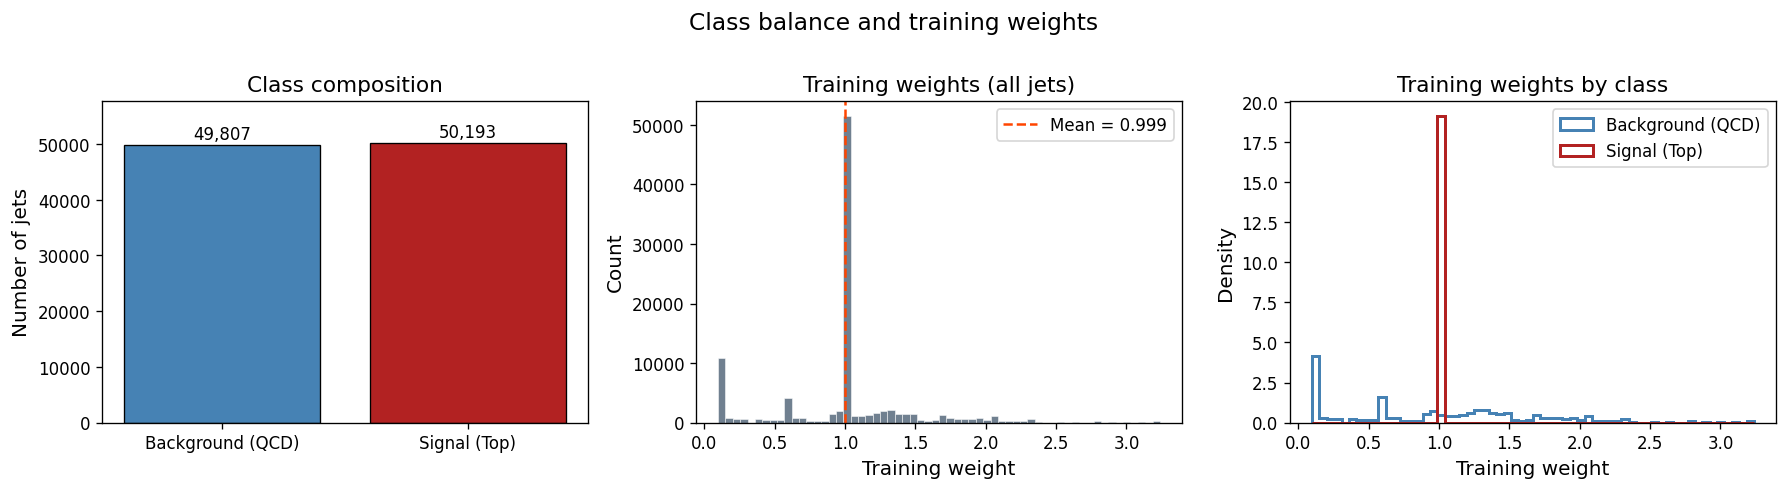

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Bar chart of label counts ───────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(
    [LABEL_NAMES[0], LABEL_NAMES[1]],
    [n_bkg, n_sig],
    color=[LABEL_COLORS[0], LABEL_COLORS[1]],
    edgecolor="black",
    linewidth=0.8,
)
for bar, count in zip(bars, [n_bkg, n_sig]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{count:,}",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_ylabel("Number of jets")
ax.set_title("Class composition")
ax.set_ylim(0, max(n_bkg, n_sig) * 1.15)

# ── 2. Training weights — all jets ─────────────────────────────────────────────
ax = axes[1]
ax.hist(training_weights, bins=60, color="slategray", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Training weight")
ax.set_ylabel("Count")
ax.set_title("Training weights (all jets)")
ax.axvline(training_weights.mean(), color="orangered", ls="--", label=f"Mean = {training_weights.mean():.3f}")
ax.legend()

# ── 3. Training weights split by label ────────────────────────────────────────
ax = axes[2]
bins_w = np.linspace(training_weights.min(), training_weights.max(), 61)
for lbl in [0, 1]:
    mask = labels == lbl
    ax.hist(
        training_weights[mask], bins=bins_w,
        histtype="step", linewidth=1.8,
        density=True,
        color=LABEL_COLORS[lbl], label=LABEL_NAMES[lbl],
    )
ax.set_xlabel("Training weight")
ax.set_ylabel("Density")
ax.set_title("Training weights by class")
ax.legend()

plt.suptitle("Class balance and training weights", fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("01_label_balance_and_weights.png")
plt.show()

**Observations:**

- The dataset is nearly perfectly balanced in terms of raw class counts: ~50.2% signal, ~49.8% background. This is by design, and it means that a trivial classifier predicting all-signal or all-background would achieve roughly 50% accuracy ( well-defined chance level ).
- However, the training-weight distributions are not identical for signal and background. Signal weights are sharply concentrated around one, while background weights are more broadly distributed. This indicates that the weights encode more than class balancing: they implement a physics-motivated reweighting of the training sample and must therefore be propagated to the loss during model training.

---

## 9. Jet-Level Kinematic Distributions

We plot signal vs background distributions for the four jet-level kinematic quantities. All energies and momenta are converted from MeV to GeV.

  Saved → ../figures/02_jet_kinematics.png


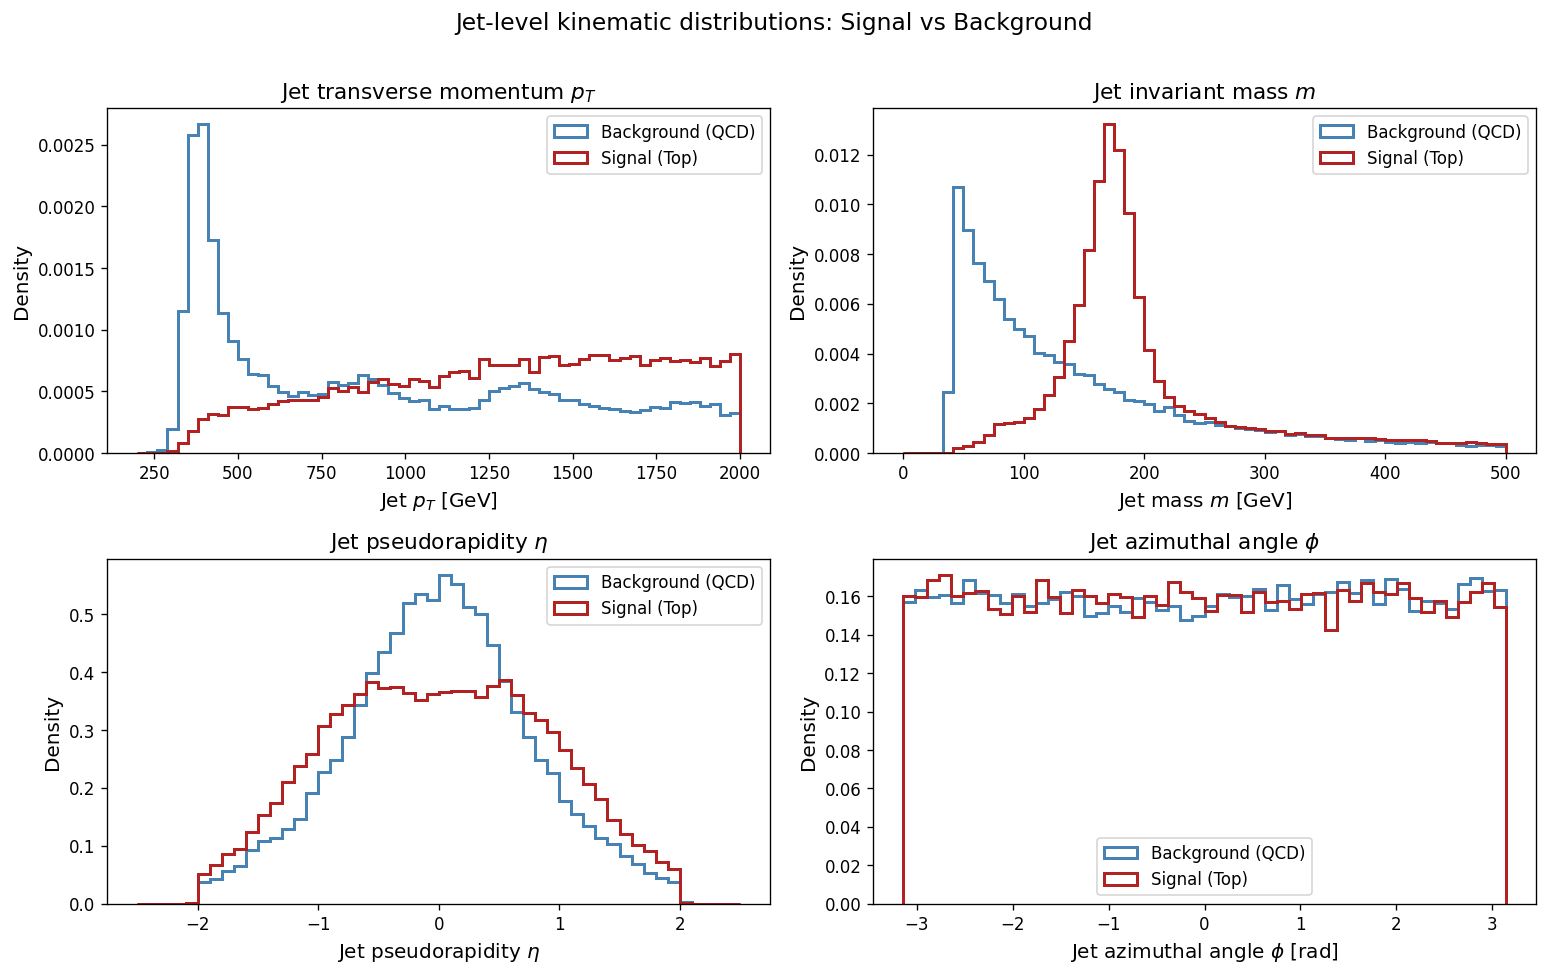

In [9]:
MEV_TO_GEV = 1e-3   # conversion factor

jet_pt_gev = jet_pt * MEV_TO_GEV
jet_m_gev  = jet_m  * MEV_TO_GEV

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── pT ────────────────────────────────────────────────────────────────────────
safe_hist_by_label(
    jet_pt_gev, labels,
    bins=np.linspace(200, 2000, 61),
    xlabel=r"Jet $p_T$ [GeV]",
    title=r"Jet transverse momentum $p_T$",
    ax=axes[0, 0],
)

# ── Mass ──────────────────────────────────────────────────────────────────────
safe_hist_by_label(
    jet_m_gev, labels,
    bins=np.linspace(0, 500, 61),
    xlabel=r"Jet mass $m$ [GeV]",
    title=r"Jet invariant mass $m$",
    ax=axes[0, 1],
)

# ── Eta ───────────────────────────────────────────────────────────────────────
safe_hist_by_label(
    jet_eta, labels,
    bins=np.linspace(-2.5, 2.5, 51),
    xlabel=r"Jet pseudorapidity $\eta$",
    title=r"Jet pseudorapidity $\eta$",
    ax=axes[1, 0],
)

# ── Phi ───────────────────────────────────────────────────────────────────────
safe_hist_by_label(
    jet_phi, labels,
    bins=np.linspace(-np.pi, np.pi, 51),
    xlabel=r"Jet azimuthal angle $\phi$ [rad]",
    title=r"Jet azimuthal angle $\phi$",
    ax=axes[1, 1],
)

plt.suptitle("Jet-level kinematic distributions: Signal vs Background", fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("02_jet_kinematics.png")
plt.show()

**Observations:**

- **$p_T$:** The jet \(p_T\) spectra are not identical: signal jets are more broadly distributed and populate the high-\(p_T\) region more strongly, while background jets are more concentrated near the lower end of the selected range. This difference is precisely one reason why training weights and careful evaluation are important.
- **Jet mass $m$:** This is a very strong discriminant. Signal jets cluster near $m_t \approx 173$ GeV, reflecting the top quark mass. Background QCD jets peak at much lower masses and fall steeply. A simple mass cut already provides significant discrimination.
- **$\eta$:** Both classes are symmetric around zero and cover a similar range. This reflects the detector acceptance and suggests no strong $\eta$-dependence in the classification. The distributions are nearly identical — $\eta$ alone is not discriminating.
- **$\phi$:** Flat and uniform for both classes, as expected from azimuthal symmetry at a collider. Completely non-discriminating on its own.

---

## 10. Constituent-Level Exploration

Each jet contains up to 200 constituents (calorimeter clusters), zero-padded. We must apply the validity mask `const_pt > 0` before computing any statistics.

In [10]:
# ── Constituent multiplicity ───────────────────────────────────────────────────
multiplicity = compute_constituent_multiplicity(const_pt)   # shape (N_jets,)

print("Constituent multiplicity statistics:")
print(f"  min  : {multiplicity.min()}")
print(f"  mean : {multiplicity.mean():.2f}")
print(f"  max  : {multiplicity.max()}")
print(f"  Fraction of jets with max constituents (200): "
      f"{(multiplicity == 200).mean()*100:.2f}%")

Constituent multiplicity statistics:
  min  : 5
  mean : 55.86
  max  : 200
  Fraction of jets with max constituents (200): 0.01%


The validity mask (lo aplicamos ahora en la siguinete celda) is required because constituent arrays are zero-padded to a fixed length of 200. Entries with `fjet_clus_pt = 0` do not correspond to physical particles, so they must be excluded from multiplicities, constituent-level statistics, angular distributions, and jet images. 

(jet real con 43 constituyentes -> 43 valores físicos + 157 ceros artificiales. Si no usamos máscara, esos ceros entrarían en medias, histogramas, ΔR, jet images, etc., y contaminarían la física.)

In [ ]:
# ── Leading constituent pT and scalar sum pT (masked) ─────────────────────────
# Replace padded zeros with NaN for safe max/sum operations
const_pt_nan = np.where(valid_mask, const_pt, np.nan)

lead_pt_gev  = np.nanmax(const_pt_nan, axis=1) * MEV_TO_GEV   # shape (N_jets,) #El Leading constituent es el constituent con mayor pT en dicho jet.
#Luego tenemos un leading constituent por cada jet
scalar_sum_pt_gev = np.nansum(np.where(valid_mask, const_pt, 0.0), axis=1) * MEV_TO_GEV
#Aplicamos otra vez el valid_mask, y donde sale False ponemos 0.0 para que no sume nada, y donde sale True ponemos el valor de const_pt para que sume normalmente.
#Asi podemos sumar solo los constituyentes reales sin preocuparnos por los ceros de padding, y luego convertimos a GeV.

# Fraction of jet pT carried by leading constituent
# Protect against division by zero (should not occur, but be safe)
with np.errstate(divide="ignore", invalid="ignore"):
    lead_fraction = np.where(
        scalar_sum_pt_gev > 0,
        lead_pt_gev / scalar_sum_pt_gev,
        np.nan,
    )
#Igual que antes, si suma es mayor que 0, calculamos la fracción, y si no, ponemos NaN para indicar que no es válido.
print(f"Leading constituent pT  — mean: {np.nanmean(lead_pt_gev):.1f} GeV")
print(f"Scalar sum constituent pT — mean: {np.nanmean(scalar_sum_pt_gev):.1f} GeV")
print(f"Lead fraction            — mean: {np.nanmean(lead_fraction):.3f}")

Leading constituent pT  — mean: 465.1 GeV
Scalar sum constituent pT — mean: 1551.5 GeV
Lead fraction            — mean: 0.281


The leading constituent is the highest $p_T$ constituent in a jet. Since constituents are ordered by decreasing $p_T$, it is usually the first valid entry. The leading $p_T$ fraction measures how concentrated the jet momentum is in its hardest constituent.

  Saved → ../figures/03_constituent_kinematics.png


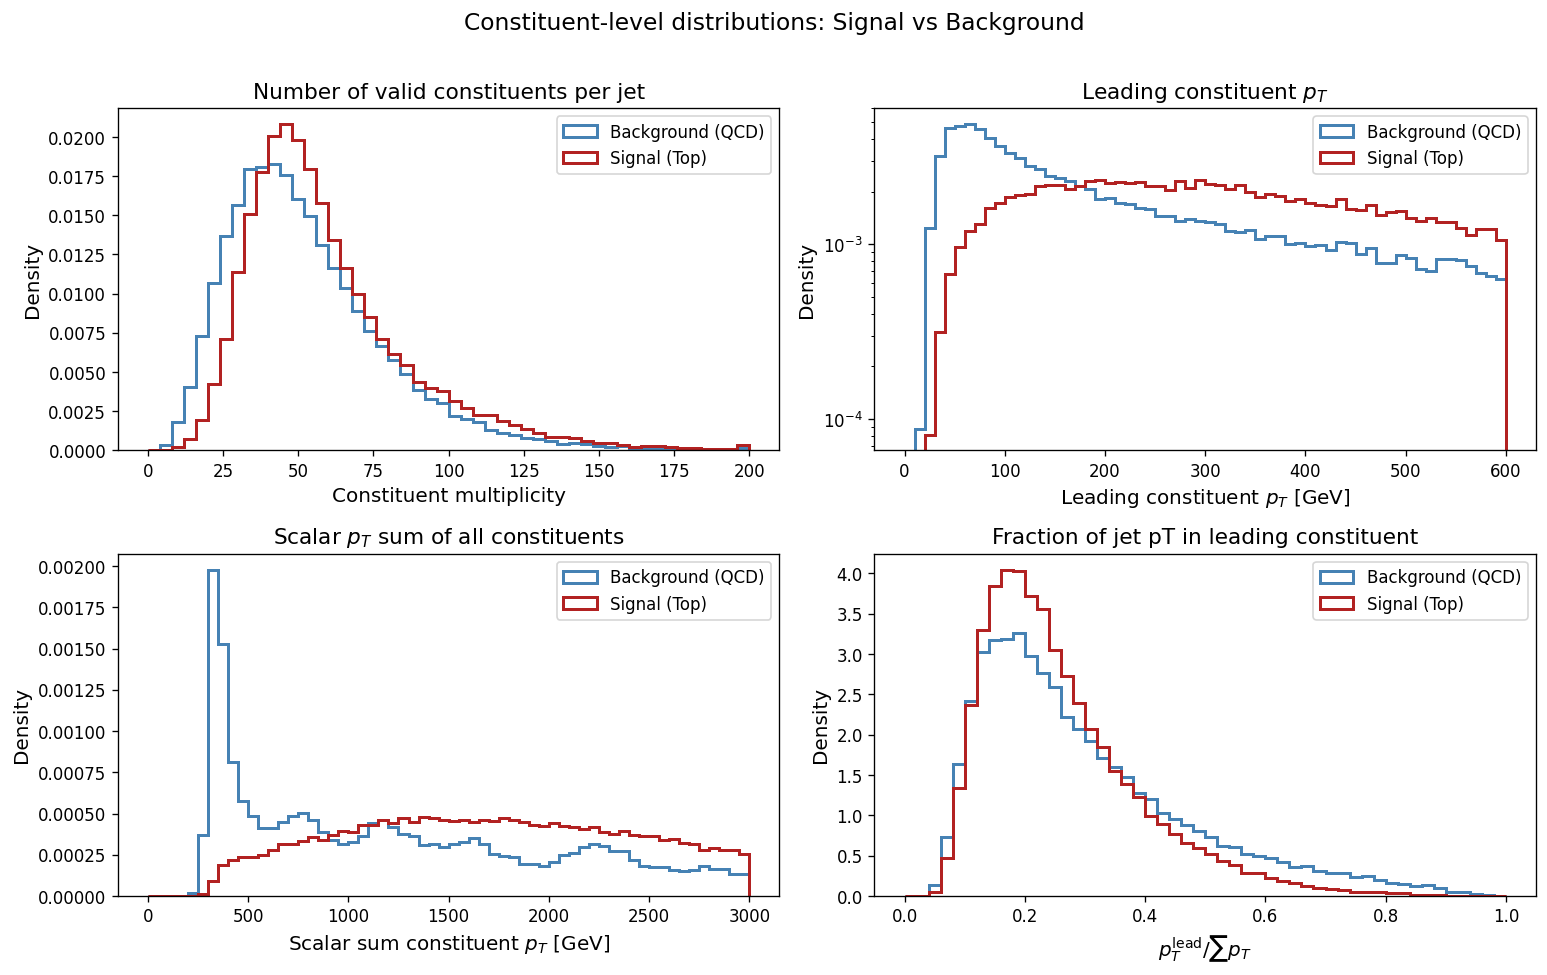

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ── Multiplicity ──────────────────────────────────────────────────────────────
safe_hist_by_label(
    multiplicity.astype(float), labels,
    bins=np.arange(0, 201, 4),
    xlabel="Constituent multiplicity",
    title="Number of valid constituents per jet",
    ax=axes[0, 0],
)

# ── Leading constituent pT ────────────────────────────────────────────────────
safe_hist_by_label(
    lead_pt_gev, labels,
    bins=np.linspace(0, 600, 61),
    xlabel=r"Leading constituent $p_T$ [GeV]",
    title=r"Leading constituent $p_T$",
    ax=axes[0, 1],
    log_y=True,
)

# ── Scalar sum pT ─────────────────────────────────────────────────────────────
safe_hist_by_label(
    scalar_sum_pt_gev, labels,
    bins=np.linspace(0, 3000, 61),
    xlabel=r"Scalar sum constituent $p_T$ [GeV]",
    title=r"Scalar $p_T$ sum of all constituents",
    ax=axes[1, 0],
)

# ── Lead fraction ─────────────────────────────────────────────────────────────
safe_hist_by_label(
    lead_fraction, labels,
    bins=np.linspace(0, 1, 51),
    xlabel=r"$p_T^{\rm lead} / \sum p_T$",
    title="Fraction of jet pT in leading constituent",
    ax=axes[1, 1],
)

plt.suptitle("Constituent-level distributions: Signal vs Background", fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("03_constituent_kinematics.png")
plt.show()

**Observations:**

- **Multiplicity:** Signal (top) jets have, on average, more constituents than background QCD jets. This is consistent with the three-prong decay producing more hadrons inside the jet cone. The distribution is broad for both classes.
- **Leading constituent $p_T$:** Signal jets tend to have larger leading-constituent $p_T$, partly reflecting their harder jet-$p_T$ spectrum. The leading fraction is more directly related to how concentrated the jet momentum is: lower values indicate that the transverse momentum is shared among more constituents, while higher values indicate a more dominant leading particle. QCD jets are more "pencil-like" with a dominant hard core.
- **Scalar sum $p_T$:** The sum over all constituent $p_T$ values reflects the total jet $p_T$. Signal jets tend to have higher sums, consistent with their harder $p_T$ spectrum.
- **Lead fraction:** Background jets show a heavier tail at large lead fractions, confirming they tend to be more dominated by a single hard constituent, a hallmark of single-prong QCD jets.

**Important:** The zero-padding means any operation on constituent arrays must be masked with `const_pt > 0`. Otherwise, padded zeros would contaminate statistics (e.g., falsely adding zero-$p_T$ "constituents" to the multiplicity count or the $\eta$/$\phi$ spread).

---

## 11. Angular Structure and $\Delta R$

We center each constituent's $\eta$–$\phi$ coordinates relative to the jet axis, then compute the angular distance $\Delta R$ from the jet axis. This reveals the radial spread of energy inside the jet.

In [13]:
# ── Center constituents relative to jet axis ───────────────────────────────────
d_eta, d_phi = center_constituents(const_eta, const_phi, jet_eta, jet_phi)

# ── Delta R for valid constituents only ────────────────────────────────────────
delta_R_all = np.sqrt(d_eta**2 + d_phi**2)   # shape (N_jets, 200)

# Flatten, keeping only valid (non-padded) constituents
dR_sig = delta_R_all[labels == 1][valid_mask[labels == 1]]
dR_bkg = delta_R_all[labels == 0][valid_mask[labels == 0]]

print(f"Valid constituent count — signal     : {dR_sig.shape[0]:,}")
print(f"Valid constituent count — background : {dR_bkg.shape[0]:,}")

Valid constituent count — signal     : 2,975,624
Valid constituent count — background : 2,610,616


The validity mask identifies which constituent entries correspond to real particles and which are only zero-padding. Since all jets are stored with a fixed length of 200 constituents, entries with `fjet_clus_pt = 0` are artificial and must not contribute to multiplicities, angular distributions, or jet-shape observables. Basicamente valid_mask es una matriz booleana del mismo tamaño que const_pt: True  -> este constituyente existe físicamente ; False -> este constituyente es padding artificial, con las mismas dimensiones (100k,200).

Así, "pT_masked = np.where(valid_mask, const_pt, 0.0)" se encarga de: Si el constituyente es real: conserva su pT ; Si es padding falso: pon pT = 0.
En este caso, como el padding ya suele tener pT=0, esta línea es casi una forma segura/limpia de asegurarnos.

No estamos eliminando entradas físicamente. No estamos reduciendo el array de (100000, 200) a listas de longitudes distintas. Tampoco estamos sustituyendo por NaN en esas dos líneas. Estamos diciendo: todo lo que sea padding cuenta como cero contribución. Así mantenemos arrays rectangulares y fáciles de operar.

  Saved → ../figures/04_angular_structure.png


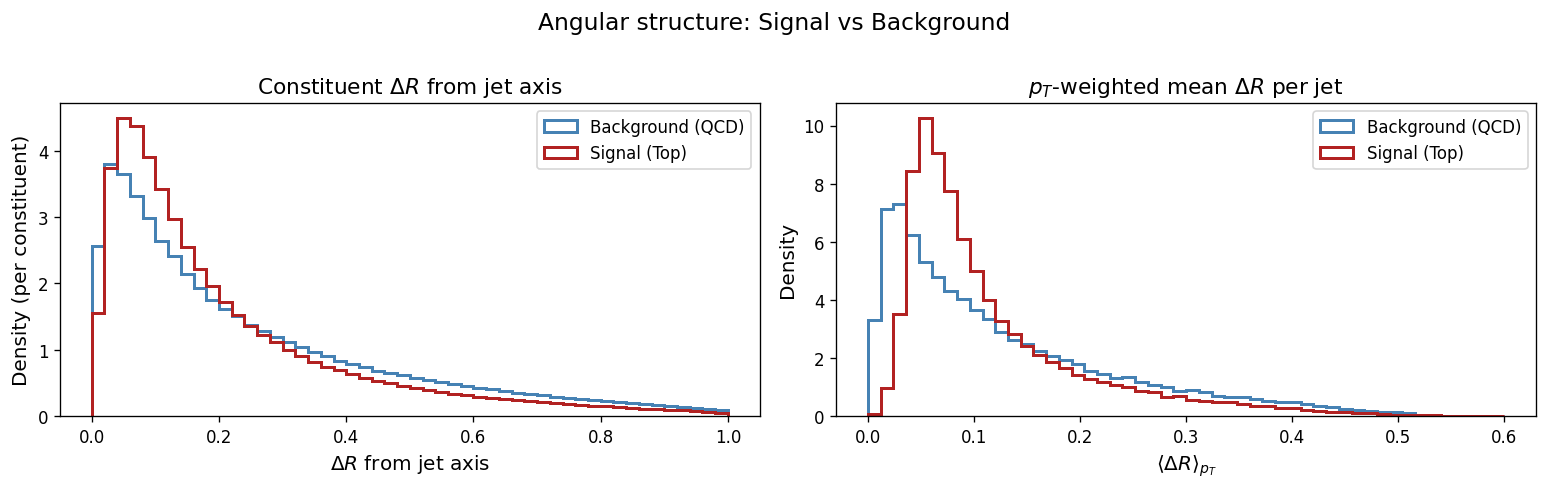

In [ ]:
# ── pT-weighted radial moment per jet ─────────────────────────────────────────
# <delta_R>_pT = sum_i (pT_i * deltaR_i) / sum_i pT_i   (valid constituents only)
pT_masked  = np.where(valid_mask, const_pt, 0.0)
dR_masked  = np.where(valid_mask, delta_R_all, 0.0)

pT_sum     = pT_masked.sum(axis=1)                         # shape (N_jets,)
pT_dR_sum  = (pT_masked * dR_masked).sum(axis=1)

with np.errstate(divide="ignore", invalid="ignore"):
    radial_moment = np.where(pT_sum > 0, pT_dR_sum / pT_sum, np.nan)
#mide la distancia radial media de los constituyentes al eje del jet, ponderada por su energía/transverse momentum. 
#Si es grande, el jet tiene su energía más extendida angularmente; si es pequeño, la energía está más cerca del eje.
# <delta_R>_pT = sum_i (pT_i * deltaR_i) / sum_i pT_i 

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── 1. Delta R distribution (per constituent) ──────────────────────────────────
ax = axes[0]
bins_dR = np.linspace(0, 1.0, 51)
ax.hist(dR_bkg, bins=bins_dR, density=True, histtype="step",
        linewidth=1.8, color=LABEL_COLORS[0], label=LABEL_NAMES[0])
ax.hist(dR_sig, bins=bins_dR, density=True, histtype="step",
        linewidth=1.8, color=LABEL_COLORS[1], label=LABEL_NAMES[1])
ax.set_xlabel(r"$\Delta R$ from jet axis")
ax.set_ylabel("Density (per constituent)")
ax.set_title(r"Constituent $\Delta R$ from jet axis")
ax.legend()

# ── 2. pT-weighted radial moment per jet ───────────────────────────────────────
safe_hist_by_label(
    radial_moment, labels,
    bins=np.linspace(0, 0.6, 51),
    xlabel=r"$\langle \Delta R \rangle_{p_T}$",
    title=r"$p_T$-weighted mean $\Delta R$ per jet",
    ax=axes[1],
)

plt.suptitle("Angular structure: Signal vs Background", fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("04_angular_structure.png")
plt.show()

**Observations:**

- **Constituent $\Delta R$:** Signal (top) jets have constituents distributed further from the jet axis on average. This reflects the wider angular spread of the three-prong decay. Background jets tend to be more concentrated near the jet core.
- **$p_T$-weighted radial moment $\langle \Delta R \rangle_{p_T}$:** This single per-jet quantity captures the energy-weighted angular spread. Signal jets have a broader distribution (larger mean $\Delta R$), quantifying their more extended structure. This observable is physically related to the jet "width" and is partially correlated with N-subjettiness ratios.

These angular distributions are directly encoded in jet images and in point-cloud representations, and they explain why both CNN and graph-based models can be powerful for this task.

The mask keeps the real constituents of each jet and removes only the padded zero entries, so jets with different physical multiplicities are all retained.

(Ejemplo: Jet A: 43 constituyentes reales + 157 ceros ; Jet B: 98 constituyentes reales + 102 ceros ; Jet C: 200 constituyentes reales + 0 ceros

Con la máscara usamos: Jet A -> solo 43 ; Jet B -> solo 98 ; Jet C -> 200)

For the $p_T$-weighted radial moment, padded entries are set to zero contribution. The observable $\sum_i p_{T,i}\Delta R_i / \sum_i p_{T,i}$ measures the typical angular distance of the jet energy from the jet axis. Weighting by $p_T$ gives more importance to energetic constituents and avoids treating very soft particles as equally relevant as the hard core of the jet. 

¡¡Weighted average, not a division by each constituent $p_T$!!. Each constituent contributes with weight $p_{T,i}/\sum_j p_{T,j}$, so high-$p_T$ constituents have a larger influence on the final value. This makes the observable sensitive to where the jet energy is located, rather than simply where the largest number of constituents are located.

---

## 12. High-Level Feature Exploration

The 15 high-level substructure features will serve as input to the first MLP baseline. We inspect their distributions and compute a summary statistics table and a correlation matrix.

In [15]:
# ── Summary statistics table ───────────────────────────────────────────────────
summary_stats = df_hl.agg(["mean", "std", "min", "max"]).T
summary_stats.columns = ["Mean", "Std", "Min", "Max"]
summary_stats = summary_stats.round(5)
print("High-level feature summary statistics:")
print(summary_stats.to_string())

High-level feature summary statistics:
                   Mean      Std      Min       Max
fjet_Tau1_wta   0.11197  0.09592  0.00082   0.77337
fjet_Tau2_wta   0.04829  0.04136  0.00010   0.39318
fjet_Tau3_wta   0.02927  0.02556  0.00000   0.25930
fjet_Tau4_wta   0.02206  0.01940  0.00000   0.18499
fjet_Split12    0.09838  0.11405  0.00068   1.72674
fjet_Split23    0.03142  0.03164  0.00012   0.72513
fjet_ECF1       1.55164  0.86822  0.14832   4.16306
fjet_ECF2       0.18077  0.26396  0.00233   4.49815
fjet_ECF3       0.00751  0.03582  0.00000   1.98082
fjet_C2         0.12359  0.08581  0.00047   0.52647
fjet_D2         1.91241  1.12246  0.03115  27.52162
fjet_Qw         0.07198  0.05804  0.00075   1.06368
fjet_L2         0.21420  0.06510  0.00233   0.36514
fjet_L3         0.07625  0.02939  0.00122   0.16025
fjet_ThrustMaj  0.84088  0.08811  0.55126   0.99964


  Saved → ../figures/05_hl_features_grid.png


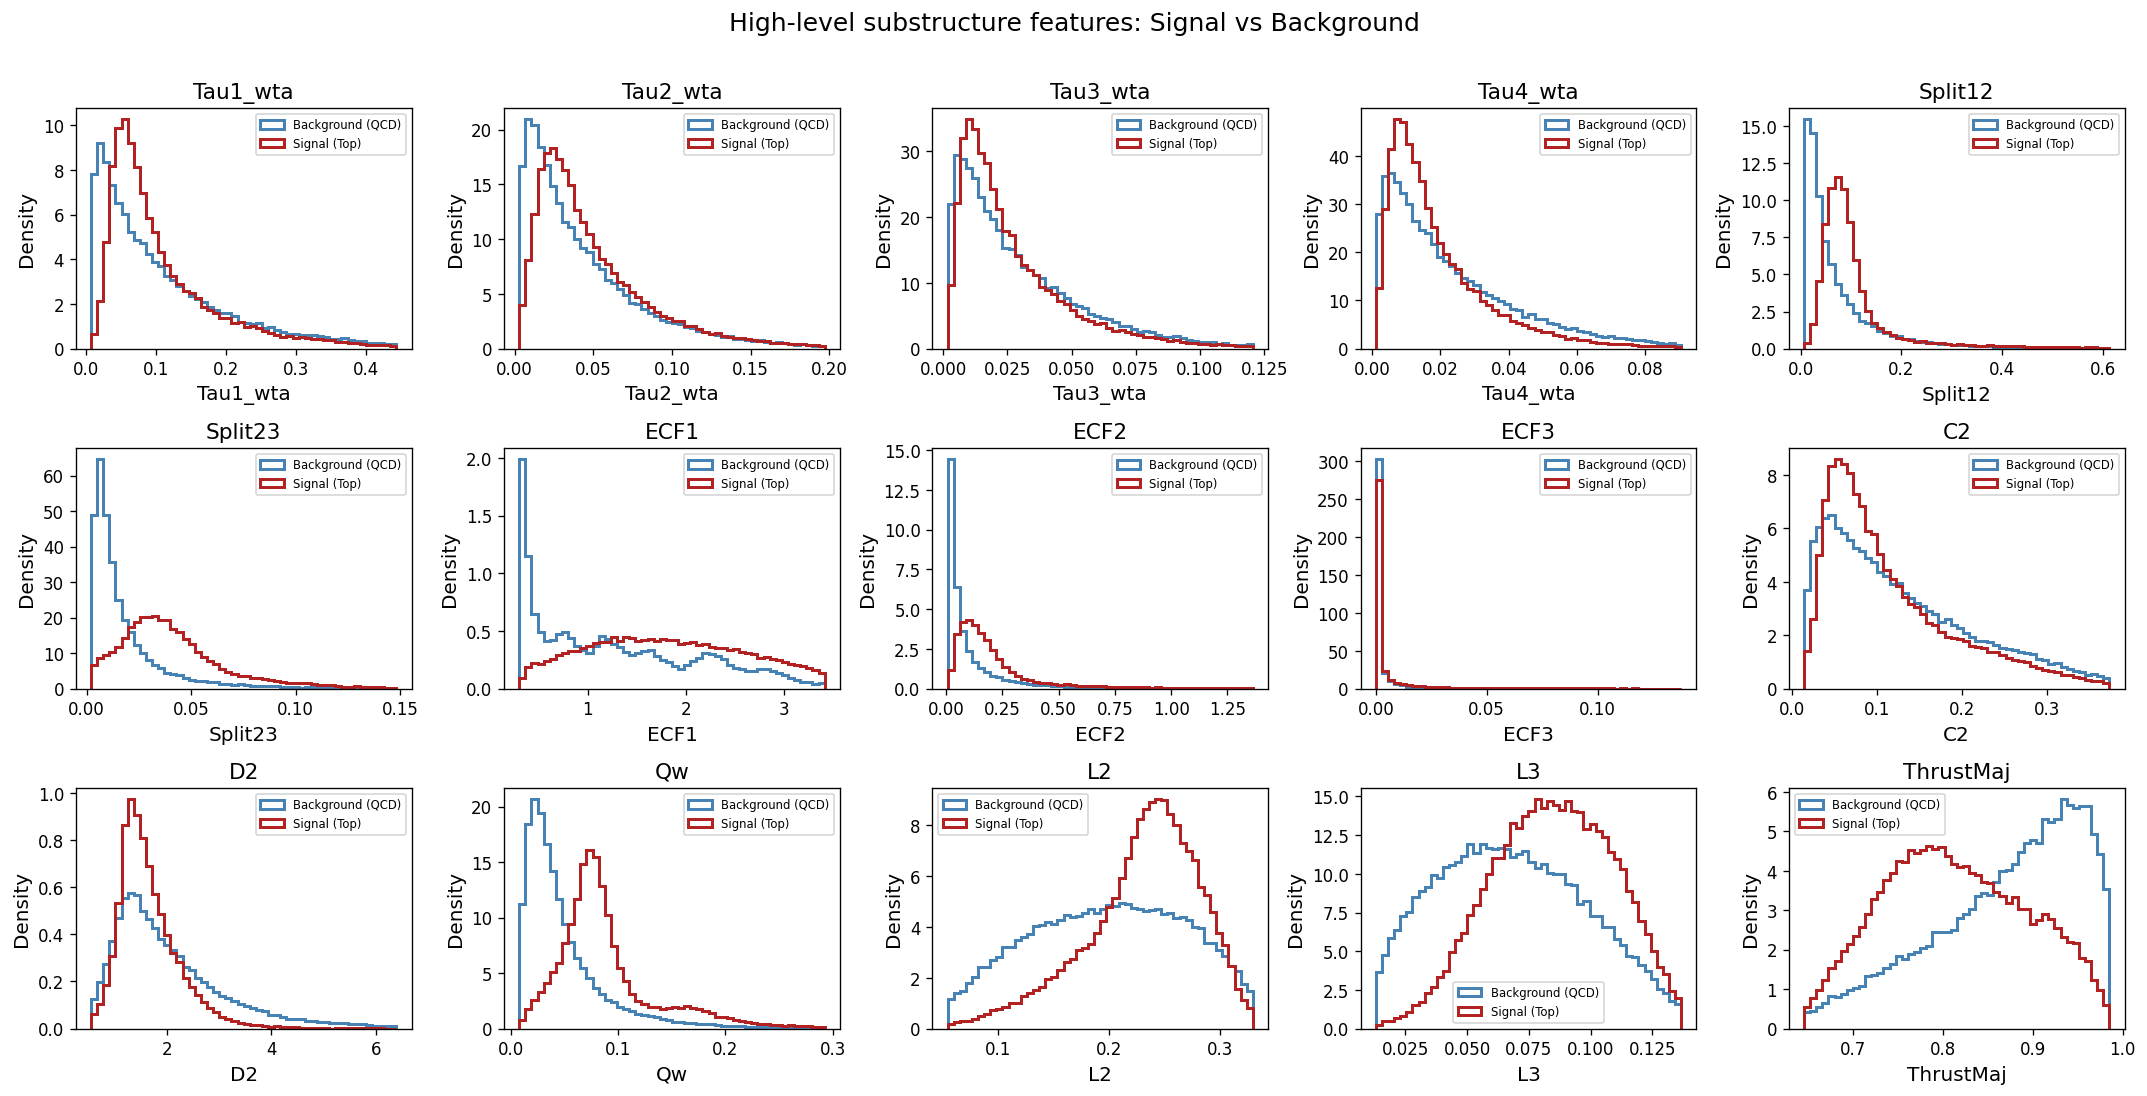

In [16]:
# ── Grid of signal vs background histograms for all 15 HL features ─────────────
n_features = len(HL_BRANCHES)
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 9))
axes = axes.flatten()

for idx, branch in enumerate(HL_BRANCHES):
    ax   = axes[idx]
    vals = df_hl[branch].values
    # Robust bin edges: clip to 1st–99th percentile to avoid extreme outliers
    lo, hi = np.nanpercentile(vals, 1), np.nanpercentile(vals, 99)
    if lo == hi:
        lo, hi = vals.min(), vals.max()
    bins = np.linspace(lo, hi, 51)
    # Short display name
    name = branch.replace("fjet_", "")
    safe_hist_by_label(vals, labels, bins=bins, xlabel=name, title=name, ax=ax)
    ax.legend(fontsize=7)

# Hide unused axes
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("High-level substructure features: Signal vs Background", fontsize=15, y=1.01)
plt.tight_layout()
save_current_figure("05_hl_features_grid.png")
plt.show()

  Saved → ../figures/06_hl_correlation_matrix.png


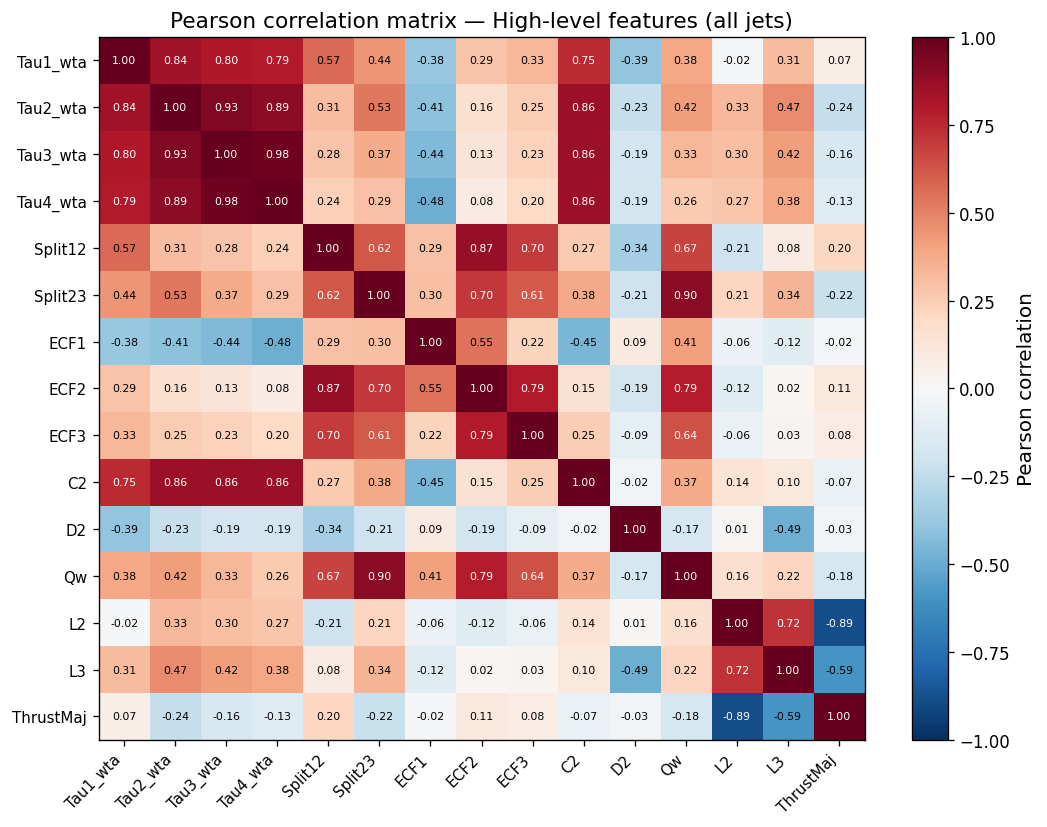

In [17]:
# ── Correlation matrix of HL features ─────────────────────────────────────────
corr = df_hl.corr()
short_names = [b.replace("fjet_", "") for b in HL_BRANCHES]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

# Annotate cells
for i in range(n_features):
    for j in range(n_features):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6.5, color=color)

ax.set_title("Pearson correlation matrix — High-level features (all jets)")
plt.tight_layout()
save_current_figure("06_hl_correlation_matrix.png")
plt.show()

**Observations:**

- **N-subjettiness** ($\tau_1$–$\tau_4$): These are the most discriminating single features. In particular, the ratio $\tau_3/\tau_2$ (not directly stored, but derivable) is a classic top tagger. Signal jets have smaller $\tau_2/\tau_1$ ratios (two axes fit the energy better than one), consistent with multi-prong structure.
- **$D_2$ and $C_2$**: Strong discriminants. $D_2$ is designed specifically to identify boosted objects with three-prong structure and peaks at different values for signal vs background.
- **Jet mass proxy ($Qw$, `fjet_Qw`)**: Shows clear separation.
- **Correlations**: Several features are highly correlated (e.g., ECF1, ECF2, ECF3 form a group; $\tau_1$–$\tau_4$ are correlated). This means a neural network will need to learn to exploit the off-diagonal correlations that linear models might miss, but also that PCA or feature selection could potentially reduce dimensionality.

These 15 features form the input to the **MLP baseline** in the next notebook.

  Saved → ../figures/07_tau_ratios.png


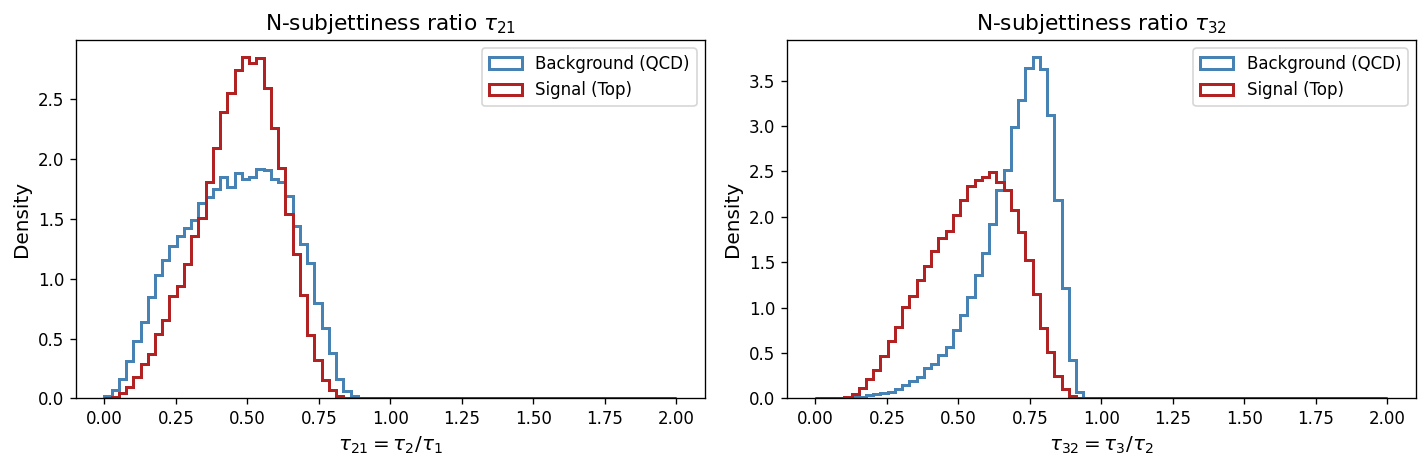

In [22]:
with np.errstate(divide="ignore", invalid="ignore"):
    tau21 = df_hl["fjet_Tau2_wta"] / df_hl["fjet_Tau1_wta"]
    tau32 = df_hl["fjet_Tau3_wta"] / df_hl["fjet_Tau2_wta"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

safe_hist_by_label(
    tau21.values, labels,
    bins=np.linspace(0, 2, 80),
    xlabel=r"$\tau_{21} = \tau_2 / \tau_1$",
    title=r"N-subjettiness ratio $\tau_{21}$",
    ax=axes[0],
)

safe_hist_by_label(
    tau32.values, labels,
    bins=np.linspace(0, 2, 80),
    xlabel=r"$\tau_{32} = \tau_3 / \tau_2$",
    title=r"N-subjettiness ratio $\tau_{32}$",
    ax=axes[1],
)

plt.tight_layout()
save_current_figure("07_tau_ratios.png")
plt.show()

---

## 13. Jet Image Visualisation

A **jet image** is a 2D representation of the jet in the $\Delta\eta$–$\Delta\phi$ plane, with each pixel value equal to the sum of constituent $p_T$ falling in that pixel. This is the natural input for CNN-based taggers.

We visualise:
1. Individual jet images (one background, one signal).
2. Averaged images over many jets of each class — these reveal the class-averaged energy flow pattern.

The image is centred on the jet axis ($\Delta\eta = 0$, $\Delta\phi = 0$) and covers $\pm 1.0$ in both directions.

In [18]:
# ── Jet image parameters ───────────────────────────────────────────────────────
IMG_RANGE   = 1.0   # ±1.0 in both delta_eta and delta_phi
IMG_PIXELS  = 40    # 40x40 pixels
IMG_BINS    = np.linspace(-IMG_RANGE, IMG_RANGE, IMG_PIXELS + 1)


def make_jet_image(
    d_eta_j:  np.ndarray,
    d_phi_j:  np.ndarray,
    pt_j:     np.ndarray,
    mask_j:   np.ndarray,
    bins:     np.ndarray = IMG_BINS,
) -> np.ndarray:
    """
    Build a 2D jet image for a single jet.

    Parameters
    ----------
    d_eta_j : shape (max_constits,) — centred constituent eta.
    d_phi_j : shape (max_constits,) — centred constituent phi.
    pt_j    : shape (max_constits,) — constituent pT [any units].
    mask_j  : shape (max_constits,) bool — True for valid constituents.
    bins    : 1-D array of bin edges (same for both axes).

    Returns
    -------
    image : 2D array, shape (len(bins)-1, len(bins)-1).
    """
    image, _, _ = np.histogram2d(
        d_eta_j[mask_j],
        d_phi_j[mask_j],
        bins=bins,
        weights=pt_j[mask_j],
    )
    return image


def plot_jet_image(
    image: np.ndarray,
    ax:    plt.Axes,
    title: str,
    cmap:  str = "viridis",
    log_scale: bool = True,
) -> None:
    """Display a jet image on an existing Axes."""
    if log_scale:
        # Add small offset to avoid log(0)
        norm = mcolors.LogNorm(vmin=max(image[image > 0].min(), 1e-3),
                               vmax=image.max())
    else:
        norm = None

    im = ax.imshow(
        image.T,           # transpose so eta is x-axis, phi is y-axis
        origin="lower",
        extent=[-IMG_RANGE, IMG_RANGE, -IMG_RANGE, IMG_RANGE],
        cmap=cmap,
        norm=norm,
        aspect="equal",
    )
    plt.colorbar(im, ax=ax, label=r"$\sum p_T$ [MeV]")
    ax.set_xlabel(r"$\Delta\eta$")
    ax.set_ylabel(r"$\Delta\phi$")
    ax.set_title(title)
    ax.axhline(0, color="white", lw=0.5, ls="--", alpha=0.5)
    ax.axvline(0, color="white", lw=0.5, ls="--", alpha=0.5)


print("Jet image functions defined.")

Jet image functions defined.


  Saved → ../figures/07_individual_jet_images.png


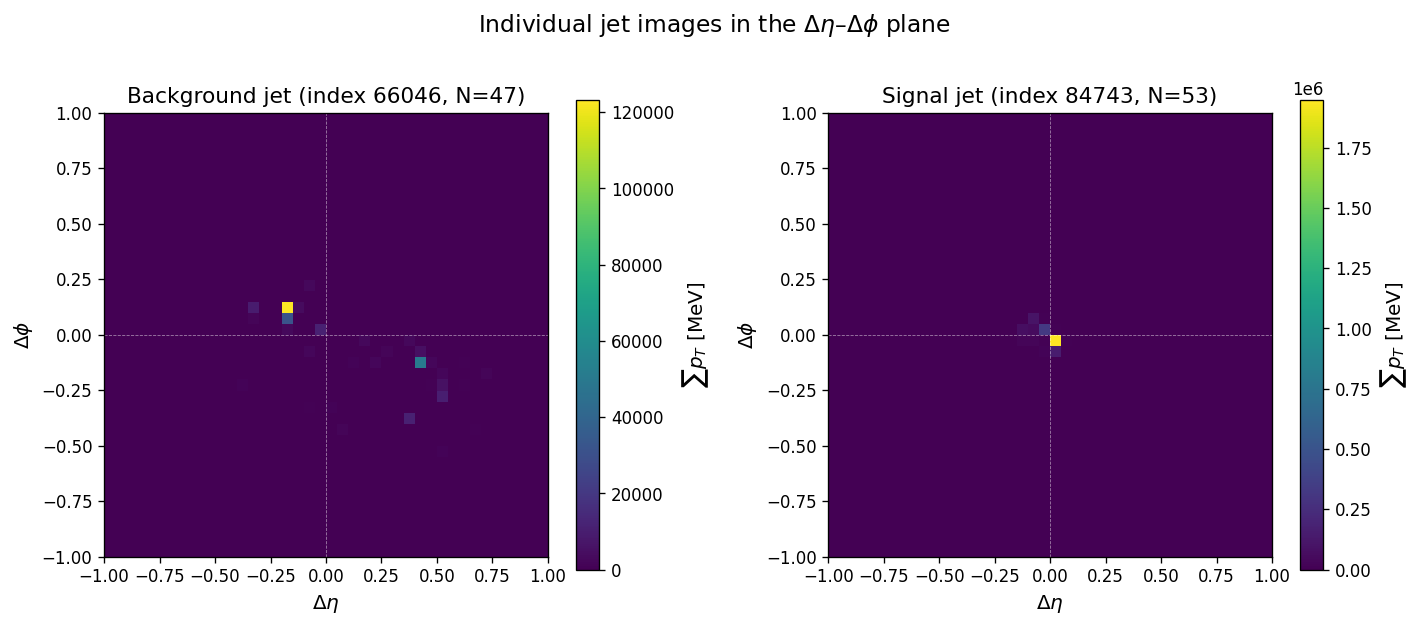

In [ ]:
# ── Centre constituents (already computed above as d_eta, d_phi) ───────────────
# Reminder: d_eta and d_phi have shape (N_jets, 200)

# ── Pick representative individual jets ────────────────────────────────────────
rng_local = np.random.default_rng(RANDOM_SEED)

bkg_indices = np.where(labels == 0)[0]
sig_indices = np.where(labels == 1)[0]

# Choose a jet with moderate multiplicity for a clean visual
bkg_med = bkg_indices[np.argsort(multiplicity[bkg_indices])][len(bkg_indices) // 2]
sig_med = sig_indices[np.argsort(multiplicity[sig_indices])][len(sig_indices) // 2]

img_bkg_single = make_jet_image(
    d_eta[bkg_med], d_phi[bkg_med], const_pt[bkg_med], valid_mask[bkg_med]
)
img_sig_single = make_jet_image(
    d_eta[sig_med], d_phi[sig_med], const_pt[sig_med], valid_mask[sig_med]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_jet_image(img_bkg_single, axes[0],
               title=f"Background jet (index {bkg_med}, N={multiplicity[bkg_med]})",
               log_scale=False)
plot_jet_image(img_sig_single, axes[1],
               title=f"Signal jet (index {sig_med}, N={multiplicity[sig_med]})",
               log_scale=False)

plt.suptitle("Individual jet images in the $\\Delta\\eta$-$\\Delta\\phi$ plane",
             fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("07_individual_jet_images.png")
plt.show()

A single jet image contains many constituents from one jet. Each constituent is placed at its relative $(\Delta\eta,\Delta\phi)$ position with an intensity proportional to its $p_T$. Thus, the image represents how the jet transverse momentum is distributed in angular space.

Computing average images over 5000 jets per class …
Done.
  Saved → ../figures/08_average_jet_images.png


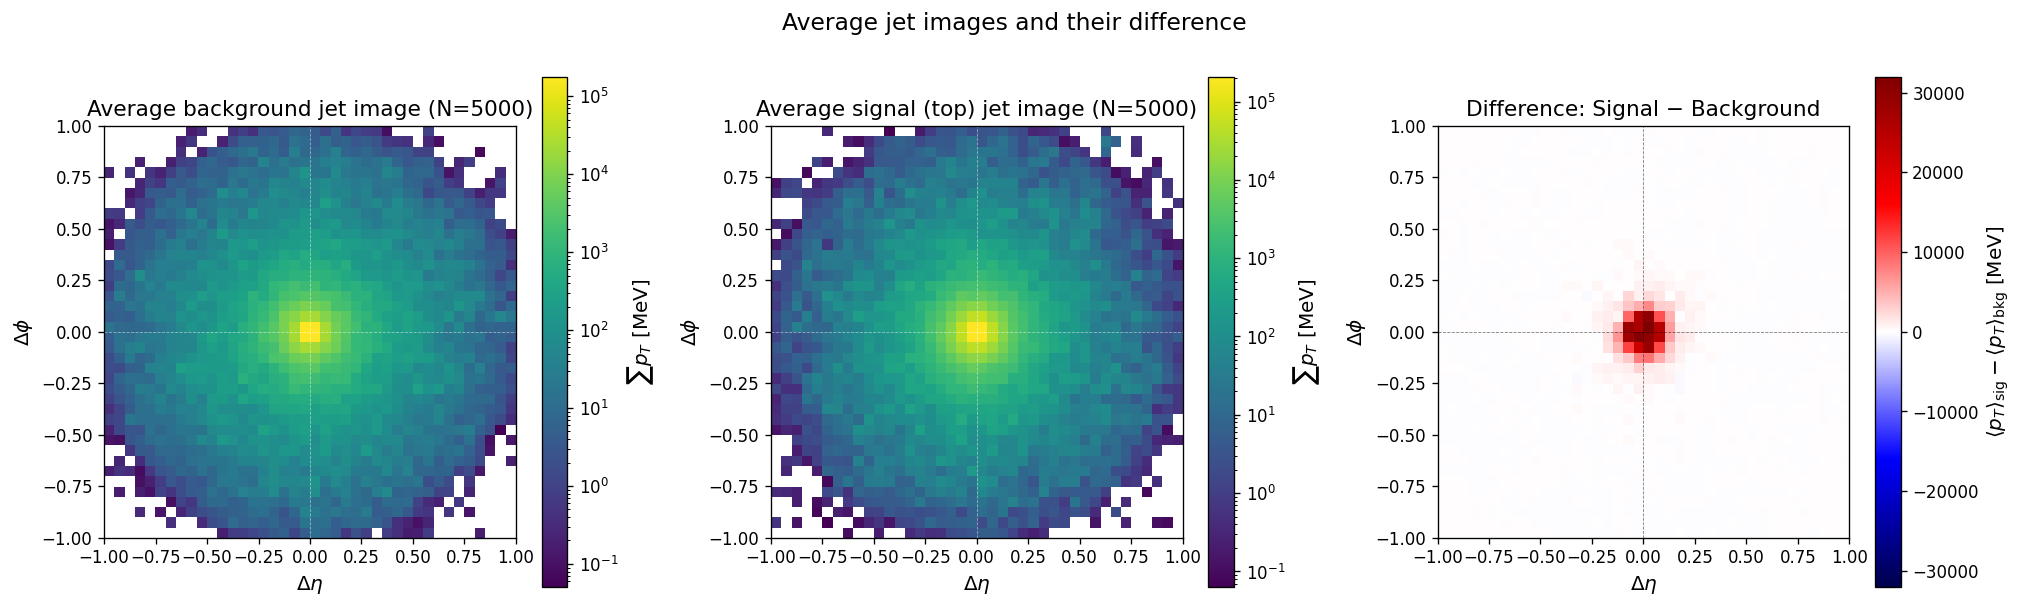

In [20]:
# ── Averaged jet images over N_AVG jets per class ─────────────────────────────
N_AVG = 5000   # number of jets to average over per class

bkg_sample = bkg_indices[:N_AVG]
sig_sample = sig_indices[:N_AVG]

def compute_average_image(
    indices: np.ndarray,
    d_eta_arr: np.ndarray,
    d_phi_arr: np.ndarray,
    pt_arr:    np.ndarray,
    mask_arr:  np.ndarray,
) -> np.ndarray:
    """Accumulate jet images and return the mean."""
    acc = np.zeros((IMG_PIXELS, IMG_PIXELS), dtype=np.float64)
    for idx in indices:
        acc += make_jet_image(d_eta_arr[idx], d_phi_arr[idx],
                              pt_arr[idx], mask_arr[idx])
    return acc / len(indices)

print(f"Computing average images over {N_AVG} jets per class …")
avg_img_bkg = compute_average_image(bkg_sample, d_eta, d_phi, const_pt, valid_mask)
avg_img_sig = compute_average_image(sig_sample, d_eta, d_phi, const_pt, valid_mask)
print("Done.")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

plot_jet_image(avg_img_bkg, axes[0],
               title=f"Average background jet image (N={N_AVG})",
               log_scale=True)
plot_jet_image(avg_img_sig, axes[1],
               title=f"Average signal (top) jet image (N={N_AVG})",
               log_scale=True)

# ── Difference image ──────────────────────────────────────────────────────────
ax = axes[2]
diff = avg_img_sig - avg_img_bkg
vmax = np.abs(diff).max()
im = ax.imshow(
    diff.T, origin="lower",
    extent=[-IMG_RANGE, IMG_RANGE, -IMG_RANGE, IMG_RANGE],
    cmap="seismic",
    vmin=-vmax, vmax=vmax,
    aspect="equal",
)
plt.colorbar(im, ax=ax, label=r"$\langle p_T \rangle_{\rm sig} - \langle p_T \rangle_{\rm bkg}$ [MeV]")
ax.set_xlabel(r"$\Delta\eta$")
ax.set_ylabel(r"$\Delta\phi$")
ax.set_title("Difference: Signal − Background")
ax.axhline(0, color="black", lw=0.5, ls="--", alpha=0.5)
ax.axvline(0, color="black", lw=0.5, ls="--", alpha=0.5)

plt.suptitle("Average jet images and their difference", fontsize=14, y=1.01)
plt.tight_layout()
save_current_figure("08_average_jet_images.png")
plt.show()

**Observations:**

- **Individual jets:** Individual jet images are sparse and stochastic. A single jet does not reveal a clean three-prong topology — fluctuations are large. This motivates learning from many examples rather than relying on eye inspection.
- **Average background jet image:** Strongly peaked at the centre ($\Delta\eta = \Delta\phi = 0$), with energy falling off rapidly. This reflects the pencil-like, single-core structure of QCD jets.
- **Average signal jet image:** More spread out, with visible energy deposits at larger radii. The centre is still energetic, but the distribution is wider.
- **Difference image (Signal − Background):** The positive (red) region shows where signal jets deposit more energy on average. The pattern reveals that top jets have excess energy at intermediate $\Delta R$, consistent with the three-prong substructure smeared by radiation and detector effects.

These average images confirm the physics picture and motivate CNN architectures: a convolutional network can learn spatially localised features from the $\Delta\eta$–$\Delta\phi$ image. In a later notebook, we will build such a network.

(A jet can have both a dense energetic core and a wider radiation pattern. Boosted top jets may contain several energetic prongs within the same large-radius jet, so their average image can show strong central activity together with a broader angular energy distribution.)